In [2]:
# Raw Data Loading
import pandas as pd

path = './creditcard.csv'
raw_data = pd.read_csv(path)
raw_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
raw_data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

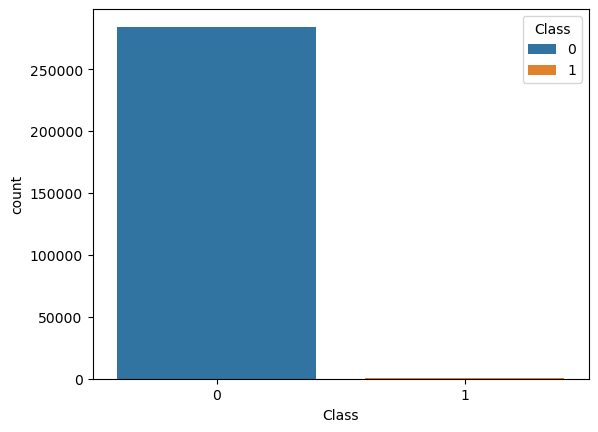

In [ ]:
# label 비율 확인
# 이런 부정사용 (사기) 데이터는 데이터의 불균형이 있을수 밖에 없음
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=raw_data, x='Class', hue='Class')

plt.show()

In [6]:
# Time feature는 제외
x = raw_data.iloc[:, 1:-1]
y = raw_data.iloc[:, -1]

x.shape, y.shape

((284807, 29), (284807,))

In [7]:
# Data Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=13)

In [8]:
# Model 평가를 위한 함수
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
def get_clf_eval(y_test, pred):
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    re = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, pred)

    return acc, pre, re, f1, auc

def print_clf_eval(y_test, pred):
    acc, pre, re, f1, auc = get_clf_eval(y_test, pred)
    confusion = confusion_matrix(y_test, pred)

    print('==> confusion matrix')
    print(confusion)
    print('====================')
    print('==> accuracy: {0:.4f}, precision: {1:.4f}'.format(acc, pre))
    print('==> recall: {0:.4f}, f1: {1:.4f}, auc: {2:.4f}'.format(re, f1, auc))

In [ ]:
# 시도 1: 전처리없이 바로 학습 (Logistic Regression)
# 불균형이 심해서 recall이 낮음 (실제 1인 데이터를 잘 예측하지 못함)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear', random_state=13)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

print_clf_eval(y_test, lr_pred)

==> confusion matrix
[[85284    11]
 [   60    88]]
==> accuracy: 0.9992, precision: 0.8889
==> recall: 0.5946, f1: 0.7126, auc: 0.7972


In [10]:
# 시도 1: 전처리없이 바로 학습 (Decision Tree Classifier)
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=4, random_state=13)
dtc.fit(x_train, y_train)
dtc_pred = dtc.predict(x_test)

print_clf_eval(y_test, dtc_pred)

==> confusion matrix
[[85281    14]
 [   42   106]]
==> accuracy: 0.9993, precision: 0.8833
==> recall: 0.7162, f1: 0.7910, auc: 0.8580


In [20]:
# 시도 1: 전처리없이 바로 학습 (Random Forest Classifier)
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100,
                             n_jobs=-1,
                             random_state=13)
rfc.fit(x_train, y_train)
rfc_pred = rfc.predict(x_test)

print_clf_eval(y_test, rfc_pred)

==> confusion matrix
[[85290     5]
 [   38   110]]
==> accuracy: 0.9995, precision: 0.9565
==> recall: 0.7432, f1: 0.8365, auc: 0.8716


In [18]:
# 시도 1: 전처리없이 바로 학습 (LightGBM)
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=1000,
                      num_leaves=64,
                      boost_from_average=False,
                      n_jobs=-1,
                      verbose=-1,
                      random_state=13)
lgbm.fit(x_train, y_train)
lgbm_pred = lgbm.predict(x_test)

print_clf_eval(y_test, lgbm_pred)

==> confusion matrix
[[85289     6]
 [   34   114]]
==> accuracy: 0.9995, precision: 0.9500
==> recall: 0.7703, f1: 0.8507, auc: 0.8851


In [19]:
# 모든 모델의 결과 DataFrame으로 만드는 함수
def get_result(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    return get_clf_eval(y_test, pred)

def get_result_pd(models, model_names, x_train, y_train, x_test, y_test):
    col_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    tmp = []

    for model in models:
        tmp.append(get_result(model, x_train, y_train, x_test, y_test))

    return pd.DataFrame(tmp, columns=col_names, index=model_names)

In [21]:
models = [lr, dtc, rfc, lgbm]
model_names = ['LogisticReg.', 'DecisionTree', 'RandomForest', 'LightGBM']

results = get_result_pd(models, model_names, x_train, y_train, x_test, y_test)

results

,accuracy,precision,recall,f1,roc_auc
LogisticReg.,0.999169,0.888889,0.594595,0.712551,0.797233
DecisionTree,0.999345,0.883333,0.716216,0.791045,0.858026
RandomForest,0.999497,0.956522,0.743243,0.836502,0.871592
LightGBM,0.999532,0.950000,0.770270,0.850746,0.885100


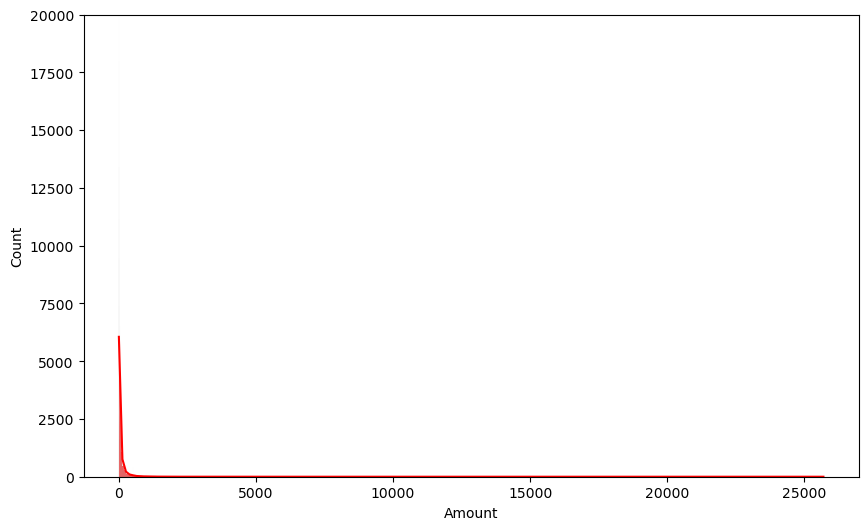

In [23]:
# 시도 2: Amount 처리 후 학습
# (대부분의 거래들은 소액에 몰려있음)
plt.figure(figsize=(10, 6))

sns.histplot(raw_data['Amount'],
             color='r',
             kde=True)

plt.ylim(0, 20000)
plt.show()

In [25]:
# 시도 2: Amount 처리 후 학습 (Standard Scaler)
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
scaled_amount = ss.fit_transform(raw_data['Amount'].values.reshape(-1, 1))

raw_data_copy = raw_data.iloc[:, 1:-2]
raw_data_copy['Scaled_Amount'] = scaled_amount

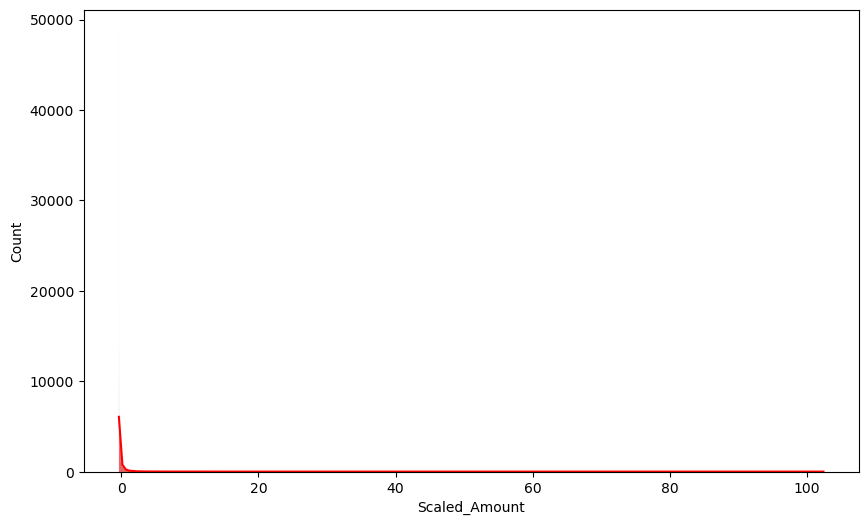

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(raw_data_copy['Scaled_Amount'], color='r', kde=True)
plt.show()

In [29]:
# Data Split
x = raw_data_copy

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=13)

In [30]:
get_result_pd(models, model_names, x_train, y_train, x_test, y_test)

,accuracy,precision,recall,f1,roc_auc
LogisticReg.,0.999169,0.888889,0.594595,0.712551,0.797233
DecisionTree,0.999345,0.883333,0.716216,0.791045,0.858026
RandomForest,0.999497,0.956522,0.743243,0.836502,0.871592
LightGBM,0.999520,0.949580,0.763514,0.846442,0.881722


In [32]:
# 시도 2: Amount 처리 후 학습 (Log Scale)
import numpy as np

amount_log = np.log1p(raw_data['Amount'])

raw_data_copy['Scaled_Amount'] = amount_log

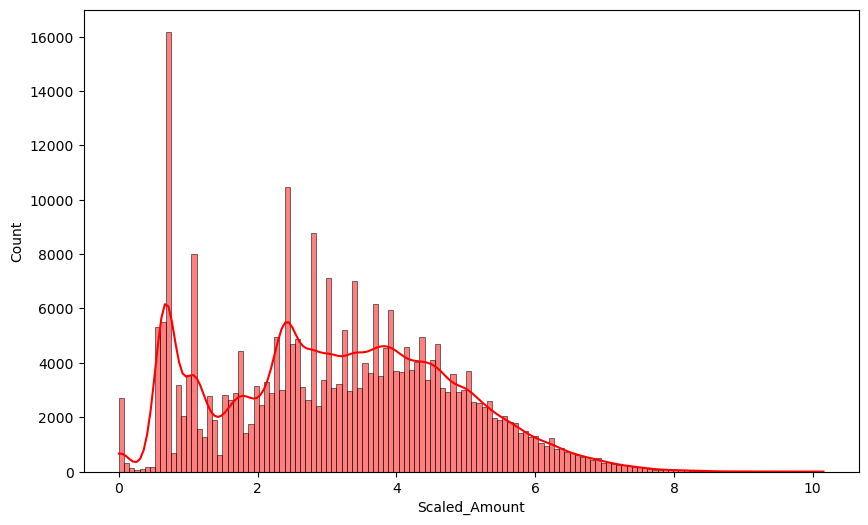

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(raw_data_copy['Scaled_Amount'], color='r', kde=True)
plt.show()

In [34]:
# Data Split
x = raw_data_copy

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=13)

In [35]:
get_result_pd(models, model_names, x_train, y_train, x_test, y_test)

,accuracy,precision,recall,f1,roc_auc
LogisticReg.,0.999157,0.887755,0.587838,0.707317,0.793854
DecisionTree,0.999345,0.883333,0.716216,0.791045,0.858026
RandomForest,0.999497,0.956522,0.743243,0.836502,0.871592
LightGBM,0.999532,0.950000,0.770270,0.850746,0.885100


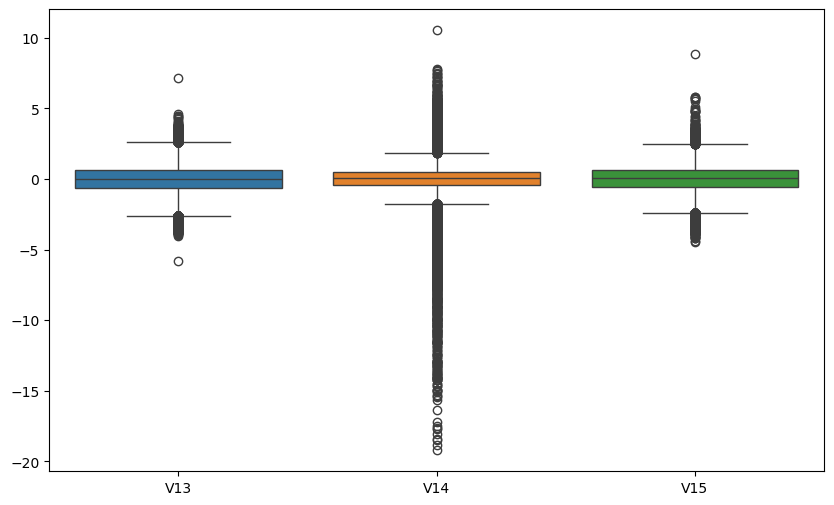

In [ ]:
# 시도 3: 이상치 처리 후 학습 (V14)
plt.figure(figsize=(10, 6))
sns.boxplot(data=raw_data[['V13', 'V14', 'V15']])
plt.show()

In [37]:
# 이상치의 인덱스를 반환하는 함수
def get_outlier(df=None, column=None, weight=1.5):
    fraud = df[df['Class'] == 1][column]

    q1 = np.percentile(fraud.values, 25)
    q3 = np.percentile(fraud.values, 75)
    iqr = q3 - q1

    lower_bound = q1 - iqr * weight
    upper_bound = q3 + iqr * weight

    outlier_index = fraud[(fraud < lower_bound) | (fraud > upper_bound)].index

    return outlier_index

In [38]:
get_outlier(df=raw_data, column='V14')

Index([8296, 8615, 9035, 9252], dtype='int64')

In [ ]:
# 이상치 제거
outlier_index = get_outlier(df=raw_data, column='V14')

raw_data_copy.drop(outlier_index, axis=0, inplace=True)
raw_data.drop(outlier_index, axis=0, inplace=True)

In [42]:
x = raw_data_copy
y = raw_data.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=13)

In [43]:
get_result_pd(models, model_names, x_train, y_train, x_test, y_test)

,accuracy,precision,recall,f1,roc_auc
LogisticReg.,0.999286,0.904762,0.650685,0.756972,0.825284
DecisionTree,0.999427,0.870229,0.780822,0.823105,0.890311
RandomForest,0.999497,0.918699,0.773973,0.840149,0.886928
LightGBM,0.999602,0.951613,0.808219,0.874074,0.904074


In [44]:
# 시도 3: 불균형 데이터 처리 (SMOTE(Over Sampling))
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=13)
x_train_over, y_train_over = smote.fit_resample(x_train, y_train)

print(x_train_over.shape, y_train_over.shape)
print(np.unique(y_train, return_counts=True))
print(np.unique(y_train_over, return_counts=True))

(398040, 29) (398040,)
(array([0, 1], dtype=int64), array([199020,    342], dtype=int64))
(array([0, 1], dtype=int64), array([199020, 199020], dtype=int64))


In [45]:
get_result_pd(models, model_names, x_train_over, y_train_over, x_test, y_test)

,accuracy,precision,recall,f1,roc_auc
LogisticReg.,0.975609,0.059545,0.897260,0.111679,0.936502
DecisionTree,0.968984,0.046048,0.869863,0.087466,0.919509
RandomForest,0.999532,0.873239,0.849315,0.861111,0.924552
LightGBM,0.999485,0.875000,0.815068,0.843972,0.907435
